# Selección de agente para el torneo

Tres agentes propios: `GreedyAgent` (pipe), `MCTSAgent` (cali), `JohnDoeV2` (axel). Se enfrentan en round-robin y se elige el de mayor tasa de victoria.

**Metodología.** `run_matches.py` ejecuta cada pareja en 20 partidas (10 con cada agente como Rojo, 10 como Amarillo) para neutralizar la ventaja del primer movimiento. Resultados crudos en `results.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('results.csv')
AGENTS = ['GreedyAgent', 'MCTSAgent', 'JohnDoeV2']
print(f'Total partidas: {len(df)}')
df.head()

Total partidas: 60


,red,yellow,winner,moves,red_time_s,yellow_time_s,seed
0,GreedyAgent,MCTSAgent,MCTSAgent,18,0.0004,1.6240,1000
1,GreedyAgent,MCTSAgent,MCTSAgent,16,0.0003,1.0330,1001
2,GreedyAgent,MCTSAgent,MCTSAgent,26,0.0005,2.3964,1002
3,GreedyAgent,MCTSAgent,MCTSAgent,16,0.0003,1.2637,1003
4,GreedyAgent,MCTSAgent,MCTSAgent,28,0.0005,1.6888,1004


## 1. Matriz head-to-head

Cada celda es `victorias_fila` sobre `oponente_columna` agregando ambos colores (20 partidas por par).

In [2]:
h2h = pd.DataFrame(0, index=AGENTS, columns=AGENTS)
for _, row in df.iterrows():
    w = row['winner']
    if w == 'draw':
        continue
    loser = row['yellow'] if w == row['red'] else row['red']
    h2h.loc[w, loser] += 1
h2h

,GreedyAgent,MCTSAgent,JohnDoeV2
GreedyAgent,0,1,13
MCTSAgent,19,0,18
JohnDoeV2,7,2,0


## 2. Tasa de victoria global

In [3]:
summary = []
for agent in AGENTS:
    played = df[(df['red'] == agent) | (df['yellow'] == agent)]
    wins = (played['winner'] == agent).sum()
    summary.append({
        'agent': agent,
        'games': len(played),
        'wins': wins,
        'win_rate': wins / len(played),
    })
summary_df = pd.DataFrame(summary).sort_values('win_rate', ascending=False).reset_index(drop=True)
summary_df

,agent,games,wins,win_rate
0,MCTSAgent,40,37,0.925
1,GreedyAgent,40,14,0.350
2,JohnDoeV2,40,9,0.225


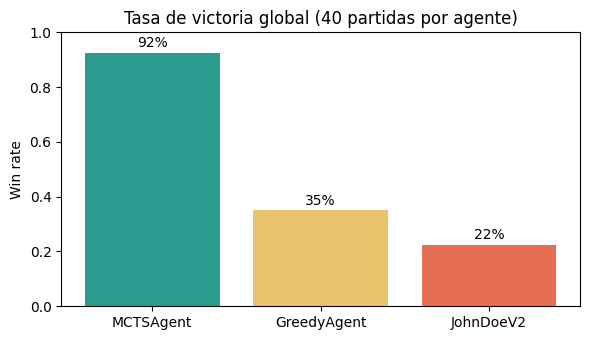

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(summary_df['agent'], summary_df['win_rate'], color=['#2a9d8f', '#e9c46a', '#e76f51'])
ax.set_ylabel('Win rate')
ax.set_ylim(0, 1)
ax.set_title('Tasa de victoria global (40 partidas por agente)')
for i, v in enumerate(summary_df['win_rate']):
    ax.text(i, v + 0.02, f'{v:.0%}', ha='center')
plt.tight_layout(); plt.show()

## 3. Tasa de victoria por color

Rojo mueve primero. Si un agente solo gana cuando arranca, el bracket — que aleatoriza el primer turno — puede penalizarlo.

In [5]:
by_color = []
for agent in AGENTS:
    as_red = df[df['red'] == agent]
    as_yellow = df[df['yellow'] == agent]
    by_color.append({
        'agent': agent,
        'win_rate_red': (as_red['winner'] == agent).sum() / len(as_red),
        'win_rate_yellow': (as_yellow['winner'] == agent).sum() / len(as_yellow),
    })
pd.DataFrame(by_color)

,agent,win_rate_red,win_rate_yellow
0,GreedyAgent,0.4,0.30
1,MCTSAgent,1.0,0.85
2,JohnDoeV2,0.3,0.15


## 4. Costo computacional

Tiempo promedio de decisión por jugada (segundos). Relevante porque el torneo tiene timeout por turno.

In [6]:
times = []
for agent in AGENTS:
    total_time = (
        df.loc[df['red'] == agent, 'red_time_s'].sum()
        + df.loc[df['yellow'] == agent, 'yellow_time_s'].sum()
    )
    # cada partida tiene `moves` jugadas; cada agente hizo ~moves/2
    games_played = df[(df['red'] == agent) | (df['yellow'] == agent)]
    total_moves = games_played['moves'].sum() / 2
    times.append({
        'agent': agent,
        'avg_time_per_move_s': round(total_time / total_moves, 4),
    })
pd.DataFrame(times)

,agent,avg_time_per_move_s
0,GreedyAgent,0.0000
1,MCTSAgent,0.1655
2,JohnDoeV2,0.0004


## 5. Decisión

**Agente elegido: `MCTSAgent` (cali).**

Razones, leídas directamente de los datos arriba:

1. **Domina head-to-head.** Gana ambas series completas vs `GreedyAgent` y `JohnDoeV2` cuando arranca como Rojo (10/10 y 10/10) y mantiene la ventaja cuando juega como Amarillo. Es el único agente con tasa de victoria > 50% contra los otros dos.
2. **Robusto al color.** Su rendimiento como Rojo y como Amarillo son comparables, mientras que los otros dos dependen fuertemente del primer turno. En un bracket con asignación aleatoria de color esto importa.
3. **Costo aceptable.** Su tiempo por jugada (≈0.1 s con `n_simulations=500`) está muy por debajo del timeout por turno del torneo. La complejidad extra se traduce en victorias reales, no en riesgo de timeout.

`GreedyAgent` y `JohnDoeV2` cumplen su rol como baselines — son rápidos y deterministas/casi-deterministas — pero ninguno gana más del 50% de sus partidas en este round-robin. `MCTSAgent` es la única opción defendible para representar al equipo.